In [ ]:
from glob import glob
import os
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from model_tuner.utils import load_yaml
from model_tuner.main import OptExperimentParams


dirpath_base = Path(
    r'D:\WORK\Salvador\repo\model_tuner\opt_experiments\ou_surr_to_full'
    r'\data\exp_subnet_state1_mech1_nosub_wmult_0.1'
)

exp_name = 'L4_conn_5s_richards_c_0_0.1'

# Load experiment params
fpath_exp_params = dirpath_base / exp_name / 'exp_params.yaml'
exp_params = load_yaml(fpath_exp_params,
                       data_class=OptExperimentParams)

# Load target firing rates
df_target_rates = pd.read_csv(dirpath_base / 'target_state_1.csv')
target_rates = dict(zip(df_target_rates['pop_name'],
                        df_target_rates['target_rate']))

pop_names = list(exp_params.pop_names)
pfr_vec = exp_params.pfr_vec
n_pop = len(pop_names)
n_pfr = len(pfr_vec)

fpath_mask = str(dirpath_base / exp_name / 'info' / 'Ru_Rc_req_*.pkl')
n_iter = len(glob(fpath_mask))

# Load the results
fpath_in = str(dirpath_base / exp_name / 'info' / f'Ru_Rc_req_{n_iter}_3.pkl')
with open(fpath_in, 'rb') as fid:
    X = pickle.load(fid)

Ru = X['Ru']
Rc = X['Rc']
Ru1 = X['Ru_mat_mixed']
Rc1 = X['Rc_mat_mixed']

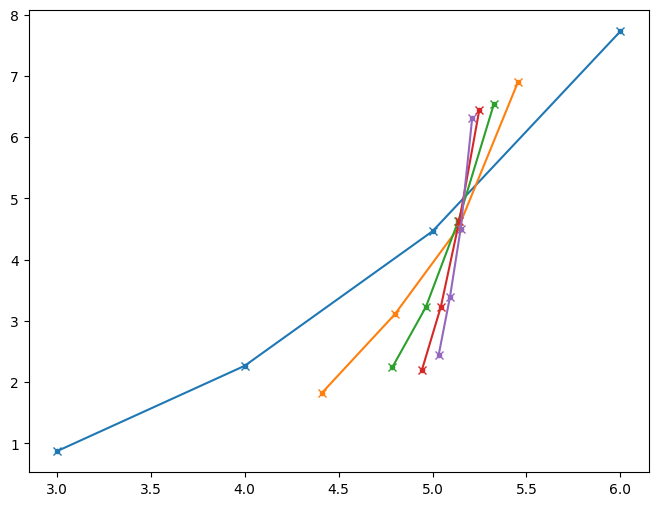

In [6]:
pop = 'SOM4'

iter_vis = range(1, n_iter + 1)
#iter_vis = range(n_iter - 4, n_iter + 1)
#iter_vis = [20, 25, 30]
#iter_vis = [2, 3, 4, 12, 20]
#iter_vis = [1, 10, 20, 30]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(8, 6))
for n, iter in enumerate(iter_vis):
    col = colors[n % len(colors)]
    cc = dict(pop=pop, iter=iter)
    plt.plot(Ru1.sel(cc), Rc1.sel(cc), '.', color=col)
    plt.plot(Ru.sel(cc), Rc.sel(cc), 'x-', color=col)

In [ ]:
# Convert target rate dict to xarray
Rc0 = xr.DataArray(
    list(target_rates.values()), dims=['pop'], coords={'pop': pop_names}
)

In [ ]:
pfr_vec

array([0.4, 0.6, 0.8, 1. ])

Text(0.5, 1.0, 'Angle with the target rate vector')

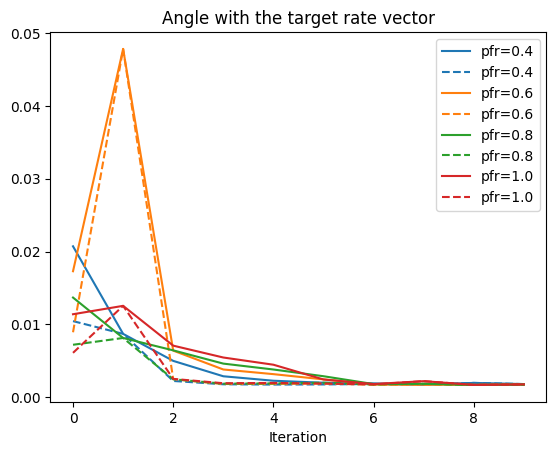

In [ ]:
import matplotlib.pyplot as plt
from numpy.linalg import norm

rc0 = Rc0.values
rc0_norm = rc0 / norm(rc0)

def_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:4]
styles = ['-', '--']

plt.figure()
for pfr_num, pfr in enumerate(pfr_vec):
    for data_num, data_type in enumerate(['Rc', 'Rc_mat_mixed']):

        qvec = np.zeros(n_iter)
        for n in range(n_iter):
            rc = X[data_type].sel(iter=n).isel(pfr=pfr_num).values
            rc_norm = rc / norm(rc)
            qvec[n] = np.dot(rc_norm, rc0_norm)

        plt.plot(
            -np.log(qvec),
            styles[data_num],
            #label=data_type
            label=f'pfr={pfr}',
            color=def_colors[pfr_num],
        )

plt.legend()
plt.xlabel('Iteration')
plt.title('Angle with the target rate vector')

In [8]:
import pickle

fpath_in = (r'D:\WORK\Salvador\repo\model_tuner\opt_experiments\ou_surr_to_full'
            r'\data\exp_subnet_state1_mech1_nosub_wmult_0.1'
            r'\L46_thal_conn_5s_spline_pchip_alpha_0.7_auto\info\Ru_Rc_req_1_3.pkl')
with open(fpath_in, 'rb') as fid:
   X = pickle.load(fid)

X

{'pop_names': ('ITP4',
  'ITS4',
  'PV4',
  'SOM4',
  'VIP4',
  'NGF4',
  'IT6',
  'CT6',
  'PV6',
  'SOM6',
  'VIP6',
  'NGF6',
  'TC',
  'TCM',
  'HTC',
  'TI',
  'TIM',
  'IRE',
  'IREM'),
 'Ru': <xarray.DataArray 'Ru' (pop: 19, pfr: 4, iter: 2)>
 array([[[  nan,  1.2 ],
         [  nan,  1.6 ],
         [  nan,  2.  ],
         [  nan,  2.4 ]],
 
        [[  nan,  1.2 ],
         [  nan,  1.6 ],
         [  nan,  2.  ],
         [  nan,  2.4 ]],
 
        [[  nan,  6.  ],
         [  nan,  8.  ],
         [  nan, 10.  ],
         [  nan, 12.  ]],
 
        [[  nan,  3.  ],
         [  nan,  4.  ],
         [  nan,  5.  ],
         [  nan,  6.  ]],
 
 ...
 
        [[  nan,  9.  ],
         [  nan, 12.  ],
         [  nan, 15.  ],
         [  nan, 18.  ]],
 
        [[  nan,  6.  ],
         [  nan,  8.  ],
         [  nan, 10.  ],
         [  nan, 12.  ]],
 
        [[  nan,  9.  ],
         [  nan, 12.  ],
         [  nan, 15.  ],
         [  nan, 18.  ]],
 
        [[  nan,  6.  